# Real-World Evaluation of Fashion Classification Models

## 1. Objective

The objective of this notebook is to evaluate the already trained fashion style and clothing type classifiers on a separate real-world test set.

The real-world test set contains images that are more varied than the original curated dataset. These images include more realistic conditions such as worn clothing, different image sources, less controlled backgrounds, and more varied presentation styles.

This notebook evaluates two trained models:

- the style classifier
- the clothing type classifier

The goal is to check whether the models generalize beyond the clean dataset used during the baseline experiments.

## 2. Project Context

The previous notebooks showed that both style classification and clothing type classification are feasible on the manually curated dataset.

The style classifier achieved strong baseline performance, but style recognition remains a subjective task because categories such as sporty and streetwear can visually overlap.

The clothing type classifier performed very strongly on the internal test set and also performed well on a small external test set. However, that external test set was limited in size.

Because the final recommendation system depends on both style and clothing type predictions, it is important to evaluate the models on a more realistic dataset before improving the recommendation logic further.

This notebook therefore focuses on real-world model evaluation. The models are not retrained in this notebook. They are only tested on the new real-world images.

## 3. Approach

The real-world evaluation process follows these steps:

1. Load the real-world test set from the `dataset/real_world_test` folder.
2. Extract the true style and clothing type labels from the folder structure.
3. Load the previously trained style and clothing type classifiers.
4. Predict the style and clothing type for every real-world image.
5. Compare the predictions with the true labels.
6. Generate classification reports and confusion matrices for both tasks.
7. Save the results for documentation and later analysis.

The folder structure of the real-world test set is:

```text
real_world_test/style/type/image
```

For example:

```text
real_world_test/gothic/jacket/gothic_jacket_rw_001.jpg
```

This means:

```text
true style = gothic
true type = jacket
```

## 4. Import Libraries

The notebook uses PyTorch and torchvision to load the trained models and process images. Pandas is used to store predictions, while sklearn is used for evaluation metrics such as accuracy, classification reports, and confusion matrices.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 5. Dataset Paths and Results Folder

The real-world test set is loaded from the `real_world_test` folder. The trained models are loaded from the `models` folder.

A separate results folder is created for this notebook so the real-world evaluation results are stored separately from the baseline results.

In [2]:
real_world_dir = "../dataset/real_world_test"

style_model_path = "../models/style_resnet34.pth"
type_model_path = "../models/type_resnet34.pth"

results_dir = "../results/real_world_evaluation"
os.makedirs(results_dir, exist_ok=True)

print("Real-world dataset path:", real_world_dir)
print("Style model path:", style_model_path)
print("Type model path:", type_model_path)
print("Results folder:", results_dir)

Real-world dataset path: ../dataset/real_world_test
Style model path: ../models/style_resnet34.pth
Type model path: ../models/type_resnet34.pth
Results folder: ../results/real_world_evaluation


## 6. Load the Real-World Test Set

The real-world test set is organized by both style and clothing type. Because each image has two labels, the folder structure is scanned manually instead of using `ImageFolder`.

For every image, the notebook stores:

- image path
- filename
- true style
- true clothing type

In [4]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

real_world_items = []

for style in sorted(os.listdir(real_world_dir)):
    style_path = os.path.join(real_world_dir, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            if not filename.lower().endswith(valid_extensions):
                continue

            image_path = os.path.join(type_path, filename)

            real_world_items.append({
                "image_path": image_path,
                "filename": filename,
                "true_style": style,
                "true_type": item_type
            })

real_world_df = pd.DataFrame(real_world_items)

print("Number of real-world images:", len(real_world_df))
#real_world_df.head()

Number of real-world images: 80


## 7. Dataset Overview

Before running predictions, the dataset distribution is checked to confirm that the real-world test set is balanced across the selected style and clothing type combinations.

In [5]:
real_world_distribution = pd.crosstab(
    real_world_df["true_style"],
    real_world_df["true_type"]
)

real_world_distribution

true_type,jacket,pants,shoes,tshirt
true_style,,,,
formal,5,5,5,5
gothic,5,5,5,5
sporty,5,5,5,5
streetwear,5,5,5,5


## 8. Image Transform

The same image preprocessing used during baseline evaluation is used here. Images are resized to 224 by 224 pixels, converted to tensors, and normalized using ImageNet statistics.

In [6]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 9. Load Trained Models

The real-world evaluation uses the two saved ResNet34 classifiers from the previous notebooks:

- `style_resnet34.pth`
- `type_resnet34.pth`

Both models are loaded in evaluation mode. No training is performed in this notebook.

In [7]:
style_checkpoint = torch.load(style_model_path, map_location=device)
type_checkpoint = torch.load(type_model_path, map_location=device)

style_class_names = style_checkpoint["class_names"]
type_class_names = type_checkpoint["class_names"]

print("Style classes:", style_class_names)
print("Type classes:", type_class_names)

Style classes: ['formal', 'gothic', 'sporty', 'streetwear']
Type classes: ['jacket', 'pants', 'shoes', 'tshirt']


In [8]:
def load_resnet34_classifier(checkpoint, num_classes):
    model = models.resnet34(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model

In [9]:
style_model = load_resnet34_classifier(
    style_checkpoint,
    len(style_class_names)
)

type_model = load_resnet34_classifier(
    type_checkpoint,
    len(type_class_names)
)

print("Both models loaded successfully.")

Both models loaded successfully.


## 10. Prediction Function

A helper function is used to predict both the style and clothing type of a real-world image.

The function returns:

- predicted style
- style confidence
- predicted clothing type
- clothing type confidence

In [10]:
def predict_style_and_type(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        style_outputs = style_model(input_tensor)
        type_outputs = type_model(input_tensor)

        style_probs = torch.softmax(style_outputs, dim=1)
        type_probs = torch.softmax(type_outputs, dim=1)

        style_pred_idx = torch.argmax(style_probs, dim=1).item()
        type_pred_idx = torch.argmax(type_probs, dim=1).item()

        predicted_style = style_class_names[style_pred_idx]
        predicted_type = type_class_names[type_pred_idx]

        style_confidence = style_probs[0][style_pred_idx].item()
        type_confidence = type_probs[0][type_pred_idx].item()

    return predicted_style, style_confidence, predicted_type, type_confidence

In [11]:
test_image_path = real_world_df.iloc[0]["image_path"]

predict_style_and_type(test_image_path)

('gothic', 0.4888773262500763, 'pants', 0.5087971687316895)

## 11. Run Predictions on the Real-World Test Set

The prediction function is applied to every image in the real-world test set.

The results are stored in a DataFrame containing the true labels, predicted labels, and prediction confidence scores.

In [12]:
predictions = []

for _, row in real_world_df.iterrows():
    predicted_style, style_confidence, predicted_type, type_confidence = predict_style_and_type(
        row["image_path"]
    )

    predictions.append({
        "image_path": row["image_path"],
        "filename": row["filename"],
        "true_style": row["true_style"],
        "predicted_style": predicted_style,
        "style_confidence": style_confidence,
        "true_type": row["true_type"],
        "predicted_type": predicted_type,
        "type_confidence": type_confidence
    })

predictions_df = pd.DataFrame(predictions)

predictions_df.head()

,image_path,filename,true_style,predicted_style,style_confidence,true_type,predicted_type,type_confidence
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,gothic,0.488877,jacket,pants,0.508797
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,formal,0.568624,jacket,jacket,0.587500
2,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_003.png,formal,formal,0.354021,jacket,jacket,0.485362
3,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_004.png,formal,formal,0.842411,jacket,jacket,0.703971
4,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_005.png,formal,gothic,0.428046,jacket,jacket,0.399718


## 12. Evaluate Style Classifier

The style classifier is evaluated by comparing the true style labels with the predicted style labels.

This gives a direct estimate of how well the style model generalizes to real-world images.

In [13]:
style_accuracy = accuracy_score(
    predictions_df["true_style"],
    predictions_df["predicted_style"]
)

print(f"Real-world Style Accuracy: {style_accuracy:.4f}")

Real-world Style Accuracy: 0.4750


### 12.1. Style Classification Report

In [14]:
style_report = classification_report(
    predictions_df["true_style"],
    predictions_df["predicted_style"],
    labels=style_class_names,
    target_names=style_class_names,
    output_dict=True,
    zero_division=0
)

style_report_df = pd.DataFrame(style_report).transpose()
style_report_df

,precision,recall,f1-score,support
formal,0.666667,0.300,0.413793,20.000
gothic,0.404255,0.950,0.567164,20.000
sporty,0.541667,0.650,0.590909,20.000
streetwear,0.000000,0.000,0.000000,20.000
accuracy,0.475000,0.475,0.475000,0.475
macro avg,0.403147,0.475,0.392967,80.000
weighted avg,0.403147,0.475,0.392967,80.000


### 12.2. Style Confusion Matrix

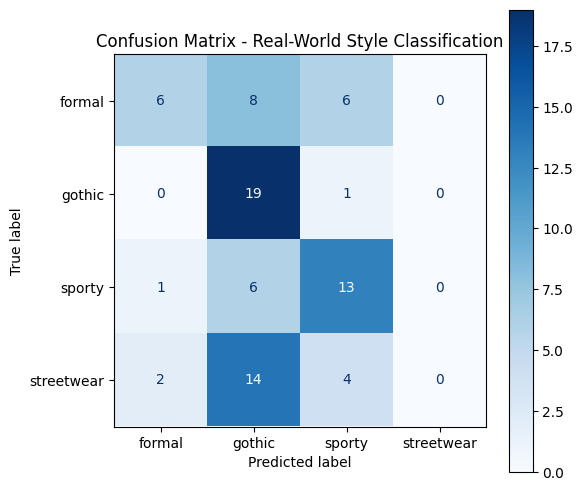

In [15]:
style_cm = confusion_matrix(
    predictions_df["true_style"],
    predictions_df["predicted_style"],
    labels=style_class_names
)

style_disp = ConfusionMatrixDisplay(
    confusion_matrix=style_cm,
    display_labels=style_class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
style_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Real-World Style Classification")
plt.show()

## 13. Evaluate Clothing Type Classifier

The clothing type classifier is evaluated by comparing the true clothing type labels with the predicted type labels.

This shows whether the type classifier remains reliable when tested on more realistic images.

In [16]:
type_accuracy = accuracy_score(
    predictions_df["true_type"],
    predictions_df["predicted_type"]
)

print(f"Real-world Type Accuracy: {type_accuracy:.4f}")

Real-world Type Accuracy: 0.7500


### 13.1. Type Classification Report

In [17]:
type_report = classification_report(
    predictions_df["true_type"],
    predictions_df["predicted_type"],
    labels=type_class_names,
    target_names=type_class_names,
    output_dict=True,
    zero_division=0
)

type_report_df = pd.DataFrame(type_report).transpose()
type_report_df

,precision,recall,f1-score,support
jacket,0.800000,0.60,0.685714,20.00
pants,0.680000,0.85,0.755556,20.00
shoes,0.800000,1.00,0.888889,20.00
tshirt,0.733333,0.55,0.628571,20.00
accuracy,0.750000,0.75,0.750000,0.75
macro avg,0.753333,0.75,0.739683,80.00
weighted avg,0.753333,0.75,0.739683,80.00


### 13.2. Type Confusion Matrix

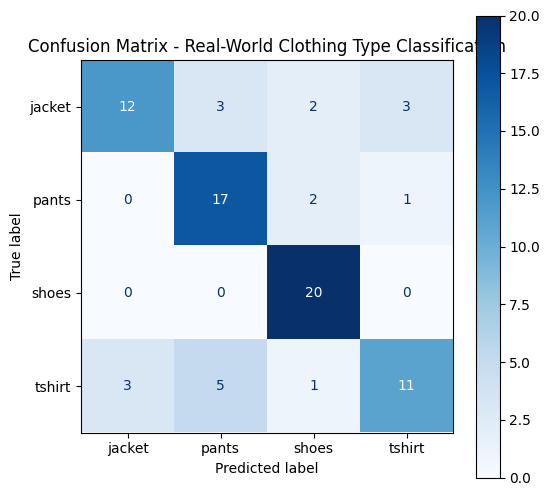

In [18]:
type_cm = confusion_matrix(
    predictions_df["true_type"],
    predictions_df["predicted_type"],
    labels=type_class_names
)

type_disp = ConfusionMatrixDisplay(
    confusion_matrix=type_cm,
    display_labels=type_class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
type_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Real-World Clothing Type Classification")
plt.show()

## 14. Inspect Incorrect Predictions

To better understand the model behavior, the incorrect predictions are inspected separately for style and clothing type.

This helps identify whether the main errors come from style confusion, clothing type confusion, or difficult real-world image conditions.

### 14.1. Incorrect Style Predictions

In [19]:
incorrect_style_df = predictions_df[
    predictions_df["true_style"] != predictions_df["predicted_style"]
].copy()

print("Incorrect style predictions:", len(incorrect_style_df))

incorrect_style_df[
    ["filename", "true_style", "predicted_style", "style_confidence", "true_type"]
]

Incorrect style predictions: 42


,filename,true_style,predicted_style,style_confidence,true_type
0,formal_jacket_rw_001.png,formal,gothic,0.488877,jacket
4,formal_jacket_rw_005.png,formal,gothic,0.428046,jacket
6,formal_pants_rw_002.png,formal,sporty,0.609268,pants
8,formal_pants_rw_004.png,formal,gothic,0.580351,pants
9,formal_pants_rw_005.png,formal,sporty,0.680293,pants
10,formal_shoes_rw_001.png,formal,gothic,0.762902,shoes
11,formal_shoes_rw_002.png,formal,gothic,0.678426,shoes
12,formal_shoes_rw_003.png,formal,gothic,0.933852,shoes
13,formal_shoes_rw_004.png,formal,gothic,0.660495,shoes
14,formal_shoes_rw_005.png,formal,gothic,0.467786,shoes


### 14.2. Incorrect Type Predictions

In [20]:
incorrect_type_df = predictions_df[
    predictions_df["true_type"] != predictions_df["predicted_type"]
].copy()

print("Incorrect type predictions:", len(incorrect_type_df))

incorrect_type_df[
    ["filename", "true_type", "predicted_type", "type_confidence", "true_style"]
]

Incorrect type predictions: 20


,filename,true_type,predicted_type,type_confidence,true_style
0,formal_jacket_rw_001.png,jacket,pants,0.508797,formal
15,formal_tshirt_rw_001.png,tshirt,jacket,0.417179,formal
16,formal_tshirt_rw_002.png,tshirt,jacket,0.469517,formal
17,formal_tshirt_rw_003.png,tshirt,pants,0.491095,formal
18,formal_tshirt_rw_004.png,tshirt,pants,0.854770,formal
19,formal_tshirt_rw_005.png,tshirt,pants,0.642829,formal
22,gothic_jacket_rw_003.png,jacket,tshirt,0.467329,gothic
37,gothic_tshirt_rw_003.png,tshirt,pants,0.584332,gothic
41,sporty_jacket_rw_002.png,jacket,pants,0.420614,sporty
42,sporty_jacket_rw_003.png,jacket,tshirt,0.624186,sporty


## 15. Visualize Some Incorrect Predictions

A few incorrect predictions are visualized to understand why the model made mistakes. This is useful because real-world image errors are often caused by background noise, pose, cropping, lighting, or visual overlap between classes.

In [21]:
def show_prediction_examples(df, title, max_images=8):
    if len(df) == 0:
        print("No examples to show.")
        return

    sample_df = df.head(max_images)

    cols = min(len(sample_df), 4)
    rows = int(np.ceil(len(sample_df) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(image)
        axes[i].set_title(
            f"True: {row['true_style']} / {row['true_type']}\n"
            f"Pred: {row['predicted_style']} / {row['predicted_type']}"
        )
        axes[i].axis("off")

    for j in range(len(sample_df), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### 15.1. Incorrect Style Prediction Examples

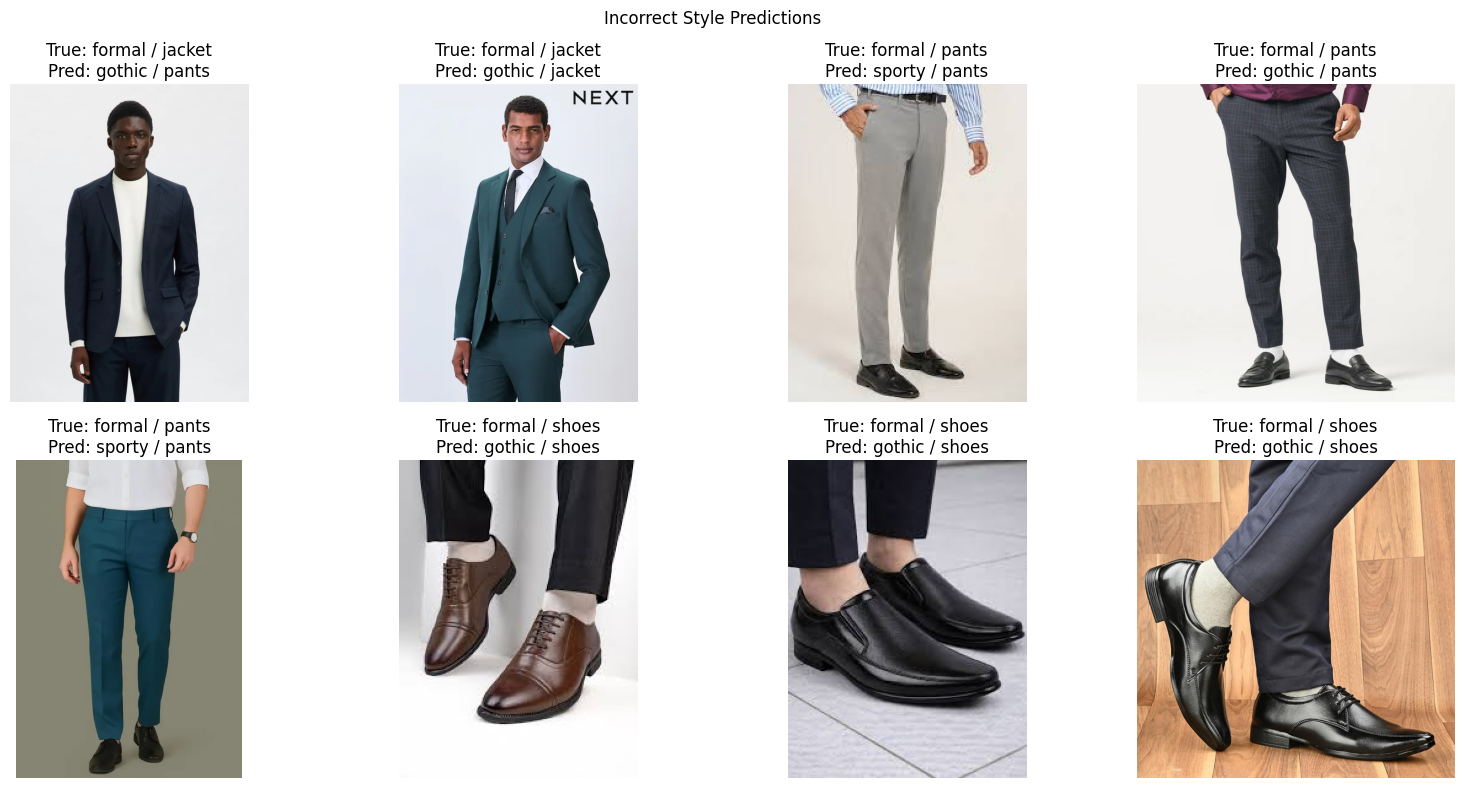

In [22]:
show_prediction_examples(
    incorrect_style_df,
    "Incorrect Style Predictions"
)

### 15.2. Incorrect Type Prediction Examples

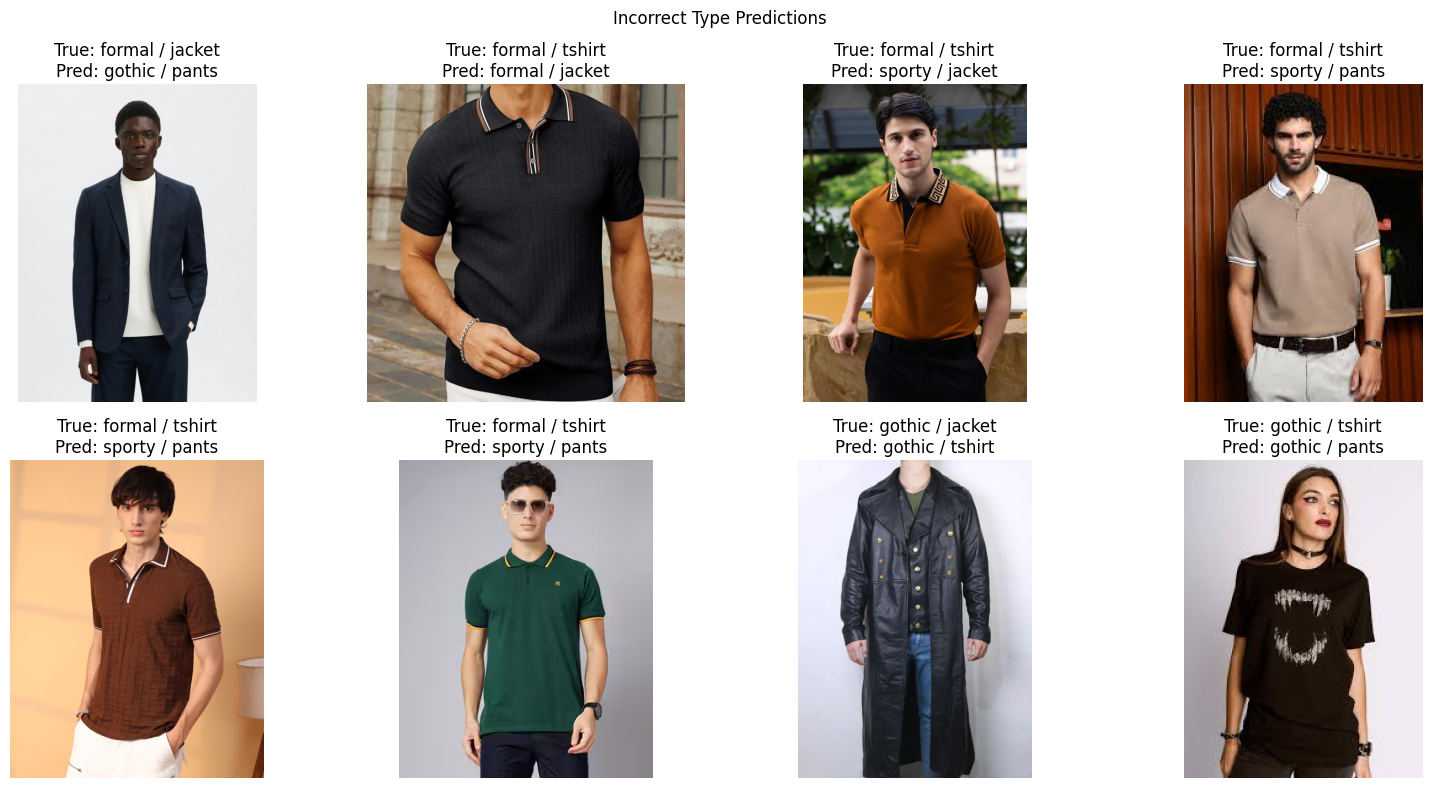

In [23]:
show_prediction_examples(
    incorrect_type_df,
    "Incorrect Type Predictions"
)

## 16. Results Comparison

The real-world results are compared with the earlier baseline results.

The style classifier previously achieved a test accuracy of **0.8417** on the curated style test set.

The clothing type classifier previously achieved an internal test accuracy of **1.00** and an external test accuracy of **0.90** on a small external test set.

The real-world test results help show whether these baseline results transfer to more realistic images.

In [24]:
comparison_df = pd.DataFrame([
    {
        "Model": "Style classifier",
        "Previous result": "0.8417 internal test accuracy",
        "Real-world result": style_accuracy
    },
    {
        "Model": "Type classifier",
        "Previous result": "1.00 internal / 0.90 small external accuracy",
        "Real-world result": type_accuracy
    }
])

comparison_df

,Model,Previous result,Real-world result
0,Style classifier,0.8417 internal test accuracy,0.475
1,Type classifier,1.00 internal / 0.90 small external accuracy,0.750


## 17. Results Interpretation

The real-world evaluation shows a clear performance drop compared with the curated baseline datasets.

The style classifier achieved a real-world accuracy of **0.4750**. This is much lower than the previous curated test accuracy of **0.8417**. This suggests that the style model learned useful patterns from the clean dataset, but it does not generalize strongly to more realistic and varied images.

The biggest issue is the **streetwear** class. Streetwear achieved **0.00 recall**, meaning that none of the real-world streetwear images were correctly predicted as streetwear. Most streetwear items were predicted as gothic or sporty. This shows that the model does not currently have a strong enough boundary between streetwear and the other visual styles.

The **gothic** class had very high recall at **0.95**, meaning that most actual gothic items were recognized. However, its precision was only **0.4043**, which means the model predicted gothic too often for items that were actually formal, sporty, or streetwear. This suggests that gothic visual features, such as dark colors or dramatic styling, may dominate the model’s decision-making.

The **formal** class also dropped in performance. Its recall was only **0.30**, meaning many formal items were predicted as gothic or sporty. This was especially visible with formal shoes and some formal tshirts, which were often classified incorrectly.

The **sporty** class performed better than streetwear and formal, with a recall of **0.65** and an F1-score of **0.5909**. However, some sporty items were still confused with gothic, especially jackets, pants, and shoes.

The clothing type classifier performed better than the style classifier, achieving a real-world accuracy of **0.7500**. This confirms the earlier observation that clothing type classification is easier than style classification because item types have clearer visual structure.

The strongest clothing type was **shoes**, with **1.00 recall** and an F1-score of **0.8889**. This means all real-world shoe images were correctly detected as shoes. The weakest type was **tshirt**, with a recall of **0.55**, because several tshirts were predicted as jackets or pants.

Overall, the results show that the type classifier is still usable for the recommendation pipeline, but the style classifier needs improvement before the system can reliably recommend items based on style. Since the recommendation system depends heavily on the predicted style, style misclassification can lead to recommendations from the wrong style category.

## 18. Limitations

This evaluation has several limitations.

First, the real-world test set contains **80 images**, with 5 images for each style and clothing type combination. This is useful for a first real-world evaluation, but it is still relatively small. A larger real-world test set would provide a more stable estimate of model performance.

Second, the real-world images are more varied than the curated dataset, but they were still manually selected and manually labeled. This means that some selection bias may still exist.

Third, style labels are subjective. Some items may reasonably fit more than one style, especially streetwear, which can overlap visually with sporty, gothic, or formal elements depending on color, fit, and styling.

Fourth, the style classifier appears to rely strongly on certain visual cues, especially dark colors. This may explain why many non-gothic items were predicted as gothic.

Fifth, this notebook evaluates only the classification models. It does not yet evaluate the full recommendation quality of the embedding-based recommendation system on real-world input images.

Despite these limitations, the evaluation is useful because it shows how the current models behave outside the clean dataset and identifies which part of the system needs improvement next.

## 19. Conclusion

This notebook evaluated the trained style and clothing type classifiers on a separate real-world test set.

The results show that the models do not generalize equally well. The style classifier achieved a real-world accuracy of **0.4750**, which is a significant drop from the curated baseline result. The main weakness was the streetwear class, which was not correctly predicted for any of the real-world streetwear images. The model also overpredicted gothic, suggesting that it may rely too heavily on dark or visually strong features.

The clothing type classifier achieved a stronger real-world accuracy of **0.7500**. This confirms that clothing type classification is more reliable than style classification in the current system. Shoes were recognized especially well, while tshirts caused more confusion.

Based on these results, the next development step should focus on improving the style classification component. This could be done by adding more varied real-world style images, refining the style definitions, improving the streetwear dataset, or experimenting with fine-tuning instead of only training the final classification layer.

The current type classifier can still be used as part of the recommendation pipeline, but the style classifier needs improvement because incorrect style predictions directly affect the quality of the generated outfit recommendations.

## 20. Saving the Results

The predictions, classification reports, confusion matrices, dataset distribution, and summary results are saved to the `results/real_world_evaluation` folder.

### 20.1. Save Predictions

In [25]:
predictions_df.to_csv(
    os.path.join(results_dir, "real_world_predictions.csv"),
    index=False
)

### 20.2. Save Classification Reports

In [26]:
style_report_df.to_csv(
    os.path.join(results_dir, "real_world_style_classification_report.csv")
)

type_report_df.to_csv(
    os.path.join(results_dir, "real_world_type_classification_report.csv")
)

### 20.3. Save Confusion Matrices

In [27]:
pd.DataFrame(
    style_cm,
    index=style_class_names,
    columns=style_class_names
).to_csv(
    os.path.join(results_dir, "real_world_style_confusion_matrix.csv")
)

pd.DataFrame(
    type_cm,
    index=type_class_names,
    columns=type_class_names
).to_csv(
    os.path.join(results_dir, "real_world_type_confusion_matrix.csv")
)

### 20.4. Save Dataset Distribution

In [28]:
real_world_distribution.to_csv(
    os.path.join(results_dir, "real_world_dataset_distribution.csv")
)

### 20.5. Save Summary

In [29]:
real_world_summary = {
    "experiment": "real_world_evaluation",
    "num_images": len(predictions_df),
    "style_accuracy": style_accuracy,
    "type_accuracy": type_accuracy,
    "style_classes": ", ".join(style_class_names),
    "type_classes": ", ".join(type_class_names),
    "main_style_issue": "streetwear had 0.00 recall and gothic was overpredicted",
    "main_type_issue": "tshirts and jackets had more confusion than shoes and pants",
    "next_step": "improve style classifier using more varied data, refined labels, or fine-tuning"
}

pd.DataFrame([real_world_summary]).to_csv(
    os.path.join(results_dir, "real_world_summary.csv"),
    index=False
)

print("Real-world evaluation results saved successfully.")

Real-world evaluation results saved successfully.
